# Datasets Preparation

In [ ]:
%run ./2_0_datasets_preparation.ipynb

# Parameters

In [34]:
water_level_area_sampling_radius_meters = 250.
coast_orientation_area_reference_radius_meters = 500.
verbose = True
show_detailed_plots = False # long output and significantly slows down computation
plots_output_root_dir = "plot/"

# 2: Grounding statistics

### 2.1 Utilities to derive the statistics

In [35]:
import numpy as np
from scipy.interpolate import interp1d
from utils import *

def tidal_phase_shift_extraction_fourier(times_sec, water_levels):
    # tidal phase p(t_epoch_sec) defined as p(t_epoch_sec) := cos(2*pi*(t_epoch_sec/(60*60*12.42)+tidal_phase_shift))
    # assert uniform time-steps for times_sec in epoch seconds
    # assert time-steps << 12h25min
    N = water_levels.shape[0]
    T = times_sec[-1]-times_sec[0] # s
    dT = T/(N-1)
    t_tides = 60*60*12.42 # tidal period in seconds
    n = int(t_tides/dT) # cut end of timeseries to have a hole number of cycles
    times_sec = times_sec[:n]
    water_levels = water_levels[:n]
    t = times_sec[-1]-times_sec[0] # s
    dt = t/(n-1)
    fft_result = np.fft.fft(water_levels)
    frequencies = np.fft.fftfreq(n, dt)
    phases_fft = np.angle(fft_result)
    interp_func = interp1d(frequencies, phases_fft, kind='linear', fill_value='extrapolate')
    phase_tides_freq = interp_func(1./t_tides)
    phase_t0 = 2*np.pi * times_sec[0]/t_tides
    tidal_phase_shift = ((phase_tides_freq-phase_t0)/(2*np.pi)) % 1.0
    return tidal_phase_shift

import numpy as np
from scipy.linalg import lstsq
def fit_plane(points_xyz):
  xyz = np.array(points_xyz)
  N = xyz.shape[1]
  A = np.c_[xyz[0], xyz[1], np.ones(N)]
  _, res, _, _ = lstsq(A,xyz[2])
  a, b, c = np.linalg.lstsq(A,xyz[2],rcond=None)[0]
  #z = ax + by + c
  return a, b, c

def NE_orientation_from_plane_parameters(a,b,c):
  #z = ax + by + c
  n_xy = [-a,-b]
  alp = (np.pi/2-np.arctan2(n_xy[1],n_xy[0])) % (2.*np.pi)
  return alp

def get_coast_orientation_plane_fit(lon, lat, area_radius):
  depths, coords_area, _ = sample_area_mesh_values(bathymetry,{"lon":lon,"lat":lat},area_radius)
  coords_area_flat = flatten_coords_deg_NE(coords_area)
  a,b,c = fit_plane([coords_area_flat[:,0], coords_area_flat[:,1], depths])
  return NE_orientation_from_plane_parameters(a,b,c) if len(depths) else np.nan, coords_area

def get_coast_orientation_gradient(lon, lat, area_radius):
  angles, coords_area, _ = sample_area_mesh_values(bathymetry_directions,{"lon":lon,"lat":lat},area_radius)
  return average_angle(angles,True)%(2.*np.pi) if len(angles) else np.nan, coords_area

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
def get_coast_orientation_multiple_methods(lon, lat, area_radius, plot):
  alp, coords = get_coast_orientation_gradient(lon, lat, area_radius)
  alp2, coords2 = get_coast_orientation_plane_fit(lon, lat, area_radius) #For comparison of gradient vs plane fit, this area radius should include one extra ring of measurements (x1.1 to x1.5)
  if(plot):
    dll = 0.0045
    colors = [(0.,0.,0.),(0.,0.,1.),(1.,1.,0.),(1.,0.,0.),(0.,1.,0.)]
    cmap = LinearSegmentedColormap.from_list("", colors, N=1000)
    fig, ax = map_plot("2x2km map 1x1km box, directions downhill: red gradient, blue planefit", add_land_coastline=[False,False], extent=[[lon-2*dll/np.cos(np.deg2rad(lat)),lon+2*dll/np.cos(np.deg2rad(lat))],[lat-2*dll,lat+2*dll]])
    plt.scatter(bathymetry["lons"], bathymetry["lats"], c=bathymetry["vals"], s=1300, marker="s", cmap=cmap,zorder=-10)
    plt.colorbar()
    X, Y, Z = bathymetry["A_grid_axes"][0], bathymetry["A_grid_axes"][1], bathymetry["A_grid_vals"]
    plt.plot([lon+i*dll/np.cos(np.deg2rad(lat)) for i in [-1,-1,1,1,-1]],[lat+i*dll for i in [-1,1,1,-1,-1]],c='black')
    depth, _, _ = sample_nearest_mesh_value(bathymetry,{"lon":lon, "lat":lat})
    plt.contour(X, Y, Z.T, levels=[depth+0.5],colors='white')
    plt.contour(X, Y, Z.T, levels=[depth+1],colors='white')
    plt.contour(X, Y, Z.T, levels=[depth],colors='gray')
    plt.contour(X, Y, Z.T, levels=[depth-0.5],colors='black') #colors = [(i/100.,i/100,np.sin(np.pi*i/100.)) for i in range(100)]*7
    plt.contour(X, Y, Z.T, levels=[depth-1],colors='black')
    plt.scatter(coords[:,0], coords[:,1],marker="o",c="red")
    plt.scatter(coords2[:,0], coords2[:,1],marker="+",c="blue")
    plt.plot([lon,lon+np.sin(alp)*(dll/2)/np.cos(np.deg2rad(lat))],[lat,lat+np.cos(alp)*(dll/2)],c='red')
    plt.plot([lon,lon+np.sin(alp2)*(dll/2)/np.cos(np.deg2rad(lat))],[lat,lat+np.cos(alp2)*(dll/2)],c='blue')
    print("angles: %.2f, %.2f" % (alp,alp2))
    plt.show()
  return alp, alp2

def get_wind_conditions(lon, lat, time):
  wind_direction, _, _ = sample_nearest_mesh_value(era5_wind_direction,{"lon":lon, "lat":lat, "time":time})
  wind_speed, _, _ = sample_nearest_mesh_value(era5_wind_speed,{"lon":lon, "lat":lat, "time":time})
  return wind_direction, wind_speed

### Computing statistics of W D events

This section creates a table with the follwing fields for each manual label event
  trajectory_no, trajectory_index, label, lon, lat, time, duration, coast_orientation, wind_direction, wind_speed, angle_wind_coast, tidal_phase

In [36]:
import pandas as pd

df = pd.DataFrame.from_dict({
  'label': [],'lon':[],'lat':[],'time':[],'trajectory_no':[],'trajectory_index':[],
  'coast_orientation_gradient':[],'coast_orientation_planefit':[],'wind_direction':[],'angle_wind_coast_gradient':[],'angle_wind_coast_planefit':[],
  'wind_speed':[],
  'tidal_phase':[],
  'duration':[]
})

show_detailed_plots_mem = show_detailed_plots # to show every 30th output even when show_detailed_plots is False
iterations_count=0
trajectories, N_traj = load_trajectories("data/out/trajectories/sample_interval_1_rnd_drop_fraction_0.00/")
for i_tr, tr in enumerate(trajectories):
  entries, ne = get_manual_labels_and_indices_where(tr) # defined in 2_0_datasets_preparation
  for ie in range(ne):
    show_detailed_plots = True if (iterations_count%30==0) else show_detailed_plots_mem
    show_detailed_plots = False #TODO remove
    iterations_count += 1
    label, i = entries.tag.values[ie], entries.ind_start.values[ie]
    if(~tr.known_minimal_duration_M2_statistics.values[i]):
      label = label+'x'
      print(label)
      print((float)(tr.dt_section[i]/(60*60)))
    time = tr.time.values[i]
    lon = tr.lon.values[i]
    lat = tr.lat.values[i]
    duration = tr.dt_section.values[i] if tr.known_minimal_duration_M2_statistics.values[i] else np.inf
    wind_direction, wind_speed = get_wind_conditions(lon, lat, time)
    coast_orientation_gradient, coast_orientation_planefit = get_coast_orientation_multiple_methods(lon, lat, coast_orientation_area_reference_radius_meters, show_detailed_plots)
    angle_wind_coast_gradient = directional_change_rad(wind_direction, coast_orientation_gradient)
    angle_wind_coast_planefit = directional_change_rad(wind_direction, coast_orientation_planefit)
    times_sec = np.linspace(time-60*60*12.42*2.1,time+60*60*12.42*2.1,100)
    water_levels = np.zeros((100,5))
    for i_time in range(100):
      water_levels[i_time,0], _, water_levels[i_time,1:] = sample_nearest_mesh_value(swanwaterlevel,{"lon":lon, "lat":lat, "time":times_sec[i_time]},water_level_area_sampling_radius_meters)
    ind_valid_series = np.var(water_levels,axis=0).argmax()
    tidal_phase = (tidal_phase_shift_extraction_fourier(times_sec,water_levels[:,ind_valid_series])+time/(60*60*12.42))%1.0
    if show_detailed_plots:
      fig, ax = plt.subplots(figsize=(8,1))
      ax.plot(times_sec,water_levels[:,0],c='red')
      ax.plot(times_sec,water_levels[:,ind_valid_series],c='orange')
      ax.plot(times_sec,np.cos(2*np.pi*((times_sec-time)/(60*60*12.42)+tidal_phase)),c='violet')
      plt.grid()
      plt.show()
    df.loc[len(df)] = [
      label,lon,lat,time,i_tr,i,
      coast_orientation_gradient,coast_orientation_planefit,wind_direction,angle_wind_coast_gradient,angle_wind_coast_planefit,
      wind_speed,
      tidal_phase,
      duration
    ]
show_detailed_plots = show_detailed_plots_mem
df = df.to_xarray()

df if verbose else None

Dx
8.707777777777778
Dx
8.97
Wx
2.9219444444444442
Ox
2.9219444444444442
Wx
3.0955555555555554
Dx
3.8733333333333335
Dx
5.764722222222222
Dx
8.309722222222222
Dx
9.016944444444444
Dx
4.463055555555556
Dx
1.4022222222222223
Dx
7.829166666666667
Dx
8.918888888888889
Dx
8.926111111111112
Dx
7.9255555555555555
Dx
9.500555555555556
Wx
3.5225


<xarray.Dataset> Size: 31kB
Dimensions:                     (index: 268)
Coordinates:
  * index                       (index) int64 2kB 0 1 2 3 4 ... 264 265 266 267
Data variables: (12/14)
    label                       (index) object 2kB 'D' 'W' 'D' ... 'O' 'D' 'Wx'
    lon                         (index) float64 2kB 4.898 4.898 ... 5.061 5.061
    lat                         (index) float64 2kB 53.1 53.1 ... 53.29 53.29
    time                        (index) float64 2kB 1.7e+09 1.7e+09 ... 1.7e+09
    trajectory_no               (index) int64 2kB 0 0 0 0 1 1 ... 29 30 30 30 30
    trajectory_index            (index) int32 1kB 668 686 933 ... 495 1122 1162
    ...                          ...
    wind_direction              (index) float64 2kB 4.171 2.945 ... 5.834 6.101
    angle_wind_coast_gradient   (index) float64 2kB -2.393 -1.143 ... 2.547
    angle_wind_coast_planefit   (index) float64 2kB -2.804 -1.645 ... 2.406
    wind_speed                  (index) float64 2kB 2.93 0.06797 ... 14.42 12.24
    tidal_phase                 (index) float64 2kB 0.8768 0.9833 ... 0.6408
    duration                    (index) float64 2kB 5.553e+03 7.646e+04 ... inf

### Visualizing statistics of W D events

In [37]:
categories_O0 = {
  'tidal_phase':np.array([[7./8.,1./8.],[1./8.,3./8.],[3./8.,5./8.],[5./8.,7./8.-.01]]),
}
categories_O1 = {
  'duration':60*60*12.42*np.array([[1.,np.inf],[1./2.,1.],[1./4.,1./2.],[0,1./4.]]),
  'wind_speed':np.array([[0,6],[6,12],[12,np.inf]]),
}
categories_O0_labels = {
  'tidal_phase':['H','F','L','R'],
}
categories_O1_labels = {
  'wind_speed':['< 6 m/s','6-12 m/s','12-18 m/s'],
  'duration':['> 1 T','1/2-1 T','1/4-1/2 T','< 1/4 T', 'unknown'],
}
label_groups = [['W'],['D']]

import matplotlib as mpl

def get_windrose_histo(max_count_bins,figsize_xy=5):
  s = max_count_bins/35. # scaling factor for dimensions
  n5_bins = int(max_count_bins/5)
  fig, ax = plt.subplots(subplot_kw=dict(projection="polar"),figsize=(figsize_xy,figsize_xy))
  ax.set_theta_zero_location("E")
  ax.set_rlabel_position(0)
  ax.set_xlim(-np.pi,np.pi)
  ax.set_xticks(np.linspace(-np.pi,np.pi,9),['0°','45°','90°','135°','180°','135°','90°','45°',''])
  print("TODO: adjust labels placement, took to long to do in the script here")
  ax.set_ylim(-10*s,max_count_bins+5)
  ax.set_yticks(np.linspace(0,max_count_bins,n5_bins+1),[['','','10','','20','','30','','40'][i] for i in range(n5_bins+1)])
  mpl.rcParams['hatch.linewidth'] = 3
  ax.fill_between(np.linspace(-np.pi/2,np.pi/2,100),-10*s*np.ones(100),-3*s*np.ones(100),zorder=50,hatch='||', fc="lightskyblue", edgecolor='blue',linewidth=3) #,color='lightskyblue'
  ax.fill_between(np.linspace(np.pi/2,np.pi*3/2,100),-10*s*np.ones(100),-3*s*np.ones(100),zorder=50,hatch='||', fc="lightgreen", edgecolor='green',linewidth=3) #,color='lightgreen'
  ax.plot([np.pi*1./2.,np.pi*3./2.],[-4,-4],zorder=50,linewidth=3*3*s,c='gold')#,linestyle='--')
  ax.grid(zorder=30)
  return fig, ax


tidal phase - wind_speed/['W']


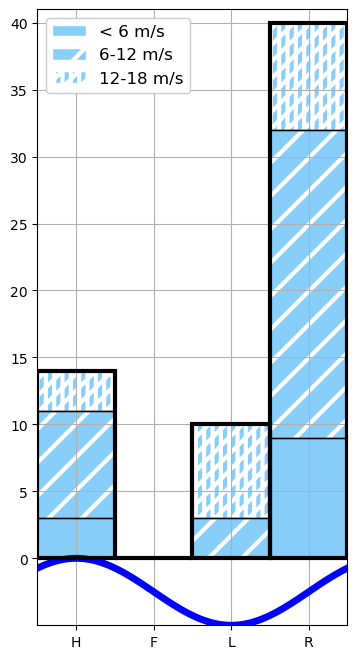

tidal phase - wind_speed/['D']


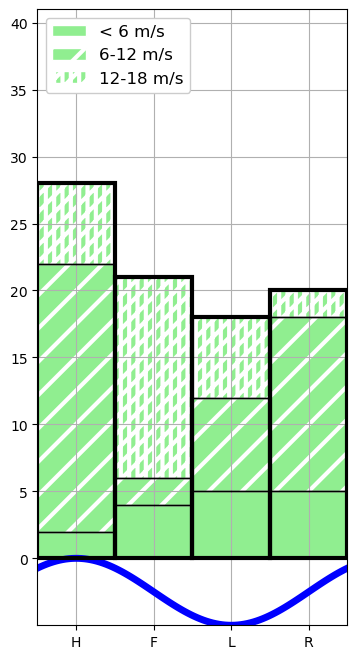

In [38]:
ctO1 = 'wind_speed'
label_color = {'W':['lightskyblue','lightskyblue','lightskyblue','lightskyblue'],'D':['lightgreen','lightgreen','lightgreen','lightgreen'],'Dx':['gray','gray','gray','gray'],'Wx':['gray','gray','gray','gray']}
hatching = [[],[''],['','//'],['','/','//||'],['','/','//','//||']]

max_y_axis_bincounts = 40
phase_shift = 1/8.#1/12.
label_groups = [['W'],['D']]
for histo_labels in label_groups:
  print('tidal phase - %s/%s' % (ctO1,histo_labels))
  data_hist = [(df.where(((df.label==label)|(df.label==label+'x'))&(c[0]<df.wind_speed)&(df.wind_speed<=c[1]),drop=True).tidal_phase+phase_shift)%1.0 for label in histo_labels for c in categories_O1[ctO1]]
  colors_hist = [label_color[label][i] for label in histo_labels for i in range(len(categories_O1[ctO1]))]
  hatching_hist = [hatching[len(categories_O1[ctO1])][i] for label in histo_labels for i in range(len(categories_O1[ctO1]))]
  fig, ax = plt.subplots(figsize=(4,8))
  n_bins = 4#6
  x_range = (0,1)
  mpl.rcParams['hatch.linewidth'] = 3
  ax.hist(data_hist, bins=n_bins, range=x_range, color=colors_hist, zorder=-10, histtype="barstacked", hatch=hatching_hist, edgecolor='white',linewidth=1, label=categories_O1_labels[ctO1]*len(histo_labels)) #, histtype="barstacked", stacked=True
  ax.hist(data_hist, bins=n_bins, range=x_range, color=[(0.,0.,0.,0.) for i in range(len(colors_hist))], zorder=10, histtype="barstacked", edgecolor='black',linewidth=1)
  ax.hist(np.concatenate(data_hist,axis=0), bins=n_bins, range=x_range, color=(0.,0.,0.,0.), edgecolor='black',zorder=10,linewidth=3)
  ax.legend(prop={'size': 12}, framealpha=1, loc="upper left") #,bbox_to_anchor=(0.4,-0.3)
  x=np.linspace(0,1,100)
  y=(np.cos(2*np.pi*(x-phase_shift))-1.)*2.5
  ax.plot(x,y,c="blue",lw=5)
  ax.set_xlim(0,1)
  ax.set_ylim(-5,max_y_axis_bincounts+1)
  ax.set_xticks(np.linspace(0,0.75,4)+phase_shift,['H','F','L','R'])
  ax.set_yticks(np.linspace(0,max_y_axis_bincounts,int(max_y_axis_bincounts/5+1)))
  ax.grid(zorder=0)
  plt.savefig("%s/groundingcharacteristics/tidalphase_%s_%s"%(plots_output_root_dir,ctO1,''.join(histo_labels)))
  plt.show()

tidal phase - duration/['W']


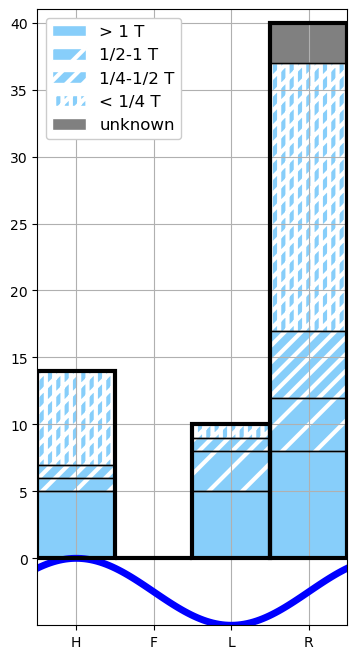

tidal phase - duration/['D']


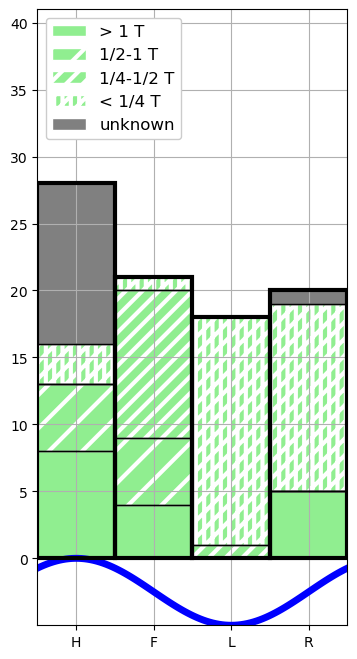

In [39]:
ctO1 = 'duration'
label_color = {'W':['lightskyblue','lightskyblue','lightskyblue','lightskyblue'],'D':['lightgreen','lightgreen','lightgreen','lightgreen'],'Dx':['gray','gray','gray','gray'],'Wx':['gray','gray','gray','gray']}
hatching = [[],[''],['','//'],['','/','//||'],['','/','//','//||']]

max_y_axis_bincounts = 40
phase_shift = 1/8.#1/12.
label_groups = [['W'],['D']]
for histo_labels in label_groups:
  print('tidal phase - %s/%s' % (ctO1,histo_labels))
  histo_labels = [histo_labels[0],histo_labels[0]+'x'] # Unknown duration events appear separate
  data_hist = [(df.where((df.label==label)&(c[0]<df.duration)&(df.duration<=c[1]),drop=True).tidal_phase+phase_shift)%1.0 for label in histo_labels for c in categories_O1[ctO1]]
  colors_hist = [label_color[label][i] for label in histo_labels for i in range(len(categories_O1[ctO1]))]
  hatching_hist = [hatching[len(categories_O1[ctO1])][i] for label in histo_labels for i in range(len(categories_O1[ctO1]))]
  fig, ax = plt.subplots(figsize=(4,8))
  n_bins = 4#6
  x_range = (0,1)
  mpl.rcParams['hatch.linewidth'] = 3
  ax.hist(data_hist, bins=n_bins, range=x_range, color=colors_hist, zorder=-10, histtype="barstacked", hatch=hatching_hist, edgecolor='white',linewidth=1, label=categories_O1_labels[ctO1]) #, histtype="barstacked", stacked=True
  ax.hist(data_hist, bins=n_bins, range=x_range, color=[(0.,0.,0.,0.) for i in range(len(colors_hist))], zorder=10, histtype="barstacked", edgecolor='black',linewidth=1)
  ax.hist(np.concatenate(data_hist,axis=0), bins=n_bins, range=x_range, color=(0.,0.,0.,0.), edgecolor='black',zorder=10,linewidth=3)
  ax.legend(prop={'size': 12}, framealpha=1, loc="upper left")
  x=np.linspace(0,1,100)
  y=(np.cos(2*np.pi*(x-phase_shift))-1.)*2.5
  ax.plot(x,y,c="blue",lw=5)
  ax.set_xlim(0,1)
  ax.set_ylim(-5,max_y_axis_bincounts+1)
  ax.set_xticks(np.linspace(0,0.75,4)+phase_shift,['H','F','L','R'])
  ax.set_yticks(np.linspace(0,max_y_axis_bincounts,int(max_y_axis_bincounts/5+1)))
  ax.grid(zorder=0)
  plt.savefig("%s/groundingcharacteristics/tidalphase_%s_%s"%(plots_output_root_dir,ctO1,''.join(histo_labels)))
  plt.show()


### Windrose plots for events with respect to the wind direction along the local coast orientation

### Wind speed

TODO: adjust labels placement, took to long to do in the script here


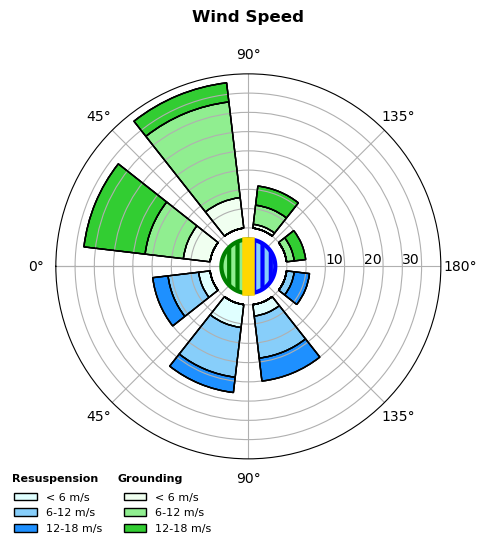

In [40]:
ctO1 = 'wind_speed'
label_color = {'W':['dodgerblue','lightskyblue','lightcyan','w'],'D':['limegreen','lightgreen','honeydew','w'],'Dx':['gray','gray','gray','gray'],'Wx':['gray','gray','gray','gray']}
hatching = [[],[''],['',''],['','',''],['','','','']]
invert_colororder = True

max_y_axis_bincounts = 35
fig, ax = get_windrose_histo(max_y_axis_bincounts)
for il, histo_labels in enumerate(label_groups):
  data_hist = [np.abs(df.where(((df.label==label)|(df.label==label+'x'))&(c[0]<df[ctO1])&(df[ctO1]<=c[1]),drop=True).angle_wind_coast_planefit)*(1. if 'D' in histo_labels else -1.) for label in histo_labels for c in categories_O1[ctO1]]
  colors_hist = [label_color[label][i if not(invert_colororder) else len(categories_O1[ctO1])-1-i] for label in histo_labels for i in range(len(categories_O1[ctO1]))]
  hatching_hist = [hatching[len(categories_O1[ctO1])][i] for label in histo_labels for i in range(len(categories_O1[ctO1]))]
  n_bins = 8
  x_range = (-np.pi,np.pi)
  mpl.rcParams['hatch.linewidth'] = 1
  ax.hist(data_hist, bins=n_bins, range=x_range, color=colors_hist, zorder=-10, histtype="barstacked", hatch=hatching_hist, edgecolor='black',linewidth=1, label=categories_O1_labels[ctO1]*len(histo_labels), rwidth=0.7) #, histtype="barstacked", stacked=True
  ax.hist(data_hist, bins=n_bins, range=x_range, color=[(0.,0.,0.,0.) for i in range(len(colors_hist))], zorder=10, histtype="barstacked", edgecolor='black',linewidth=1, rwidth=0.7)
  ax.hist(np.concatenate(data_hist,axis=0), bins=n_bins, range=x_range, color=(0.,0.,0.,0.), edgecolor='black',zorder=10,linewidth=1, rwidth=0.7)
ax.legend(prop={'size': 8},bbox_to_anchor=(0.5,-0.25), loc="lower center",ncols=3, frameon=False)
fig.text(0.04,0.065, "Resuspension", fontsize=8,fontweight='bold')
fig.text(0.25,0.065, "Grounding", fontsize=8,fontweight='bold')
ax.legend(prop={'size': 8},bbox_to_anchor=(0.43,-0.22), loc="lower right",ncols=2, frameon=False)
plt.title("Wind Speed\n",fontweight='bold')
plt.savefig("%s/groundingcharacteristics/windrose_%s_area_%dm"%(plots_output_root_dir,ctO1,2*coast_orientation_area_reference_radius_meters), dpi=300, bbox_inches="tight")
plt.show()


### Duration

TODO: adjust labels placement, took to long to do in the script here


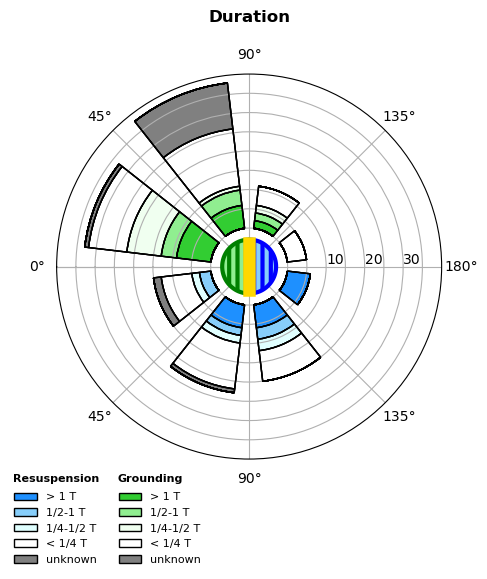

In [41]:
ctO1 = 'duration'
label_color = {'W':['dodgerblue','lightskyblue','lightcyan','w'],'D':['limegreen','lightgreen','honeydew','w'],'Dx':['gray','gray','gray','gray'],'Wx':['gray','gray','gray','gray']}
hatching = [[],[''],['',''],['','',''],['','','','']]
invert_colororder = False

max_y_axis_bincounts = 35
fig, ax = get_windrose_histo(max_y_axis_bincounts)
for il, histo_labels in enumerate(label_groups):
  data_hist = [np.abs(df.where((df.label==label)&(c[0]<df[ctO1])&(df[ctO1]<=c[1]),drop=True).angle_wind_coast_planefit)*(1. if 'D' in histo_labels else -1.) for label in histo_labels for c in categories_O1[ctO1]]
  data_hist += [np.abs(df.where((df.label==label+'x')&(c[0]<df[ctO1])&(df[ctO1]<=c[1]),drop=True).angle_wind_coast_planefit)*(1. if 'D' in histo_labels else -1.) for label in histo_labels for c in categories_O1[ctO1]]
  colors_hist = [label_color[label][i if not(invert_colororder) else len(categories_O1[ctO1])-1-i] for label in histo_labels for i in range(len(categories_O1[ctO1]))]
  colors_hist += [label_color[label+'x'][i if not(invert_colororder) else len(categories_O1[ctO1])-1-i] for label in histo_labels for i in range(len(categories_O1[ctO1]))]
  hatching_hist = [hatching[len(categories_O1[ctO1])][i] for label in histo_labels for i in range(len(categories_O1[ctO1]))]
  n_bins = 8
  x_range = (-np.pi,np.pi)
  mpl.rcParams['hatch.linewidth'] = 1
  ax.hist(data_hist, bins=n_bins, range=x_range, color=colors_hist, zorder=-10, histtype="barstacked", hatch=hatching_hist, edgecolor='black',linewidth=1, label=categories_O1_labels[ctO1]*len(histo_labels), rwidth=0.7) #, histtype="barstacked", stacked=True
  ax.hist(data_hist, bins=n_bins, range=x_range, color=[(0.,0.,0.,0.) for i in range(len(colors_hist))], zorder=10, histtype="barstacked", edgecolor='black',linewidth=1, rwidth=0.7)
  ax.hist(np.concatenate(data_hist,axis=0), bins=n_bins, range=x_range, color=(0.,0.,0.,0.), edgecolor='black',zorder=10,linewidth=1, rwidth=0.7)
fig.text(0.04,0.065, "Resuspension", fontsize=8,fontweight='bold')
fig.text(0.25,0.065, "Grounding", fontsize=8,fontweight='bold')
ax.legend(prop={'size': 8},bbox_to_anchor=(0.4,-0.3), loc="lower right",ncols=2, frameon=False)
plt.title("Duration\n",fontweight='bold')
plt.savefig("%s/groundingcharacteristics/windrose_%s_area_%dm"%(plots_output_root_dir,ctO1,2*coast_orientation_area_reference_radius_meters), dpi=300, bbox_inches="tight")
plt.show()


### Detailed heatmap plots for events separated by all considered environmental factors

This section defines functions to plot the detailed heatmap

['W']


<>:24: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:26: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:24: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:26: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/34/nx9zlnqn1z1cr2gtrfzmz7vw0000gp/T/ipykernel_15391/3814967731.py:24: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.text(j, i, "\n$\mathbf{%d}$\n%d+%d"%(np.sum(event_matrices,axis=0)[i,j],event_matrices[0,i,j],event_matrices[1,i,j]), ha="center", va="center", color

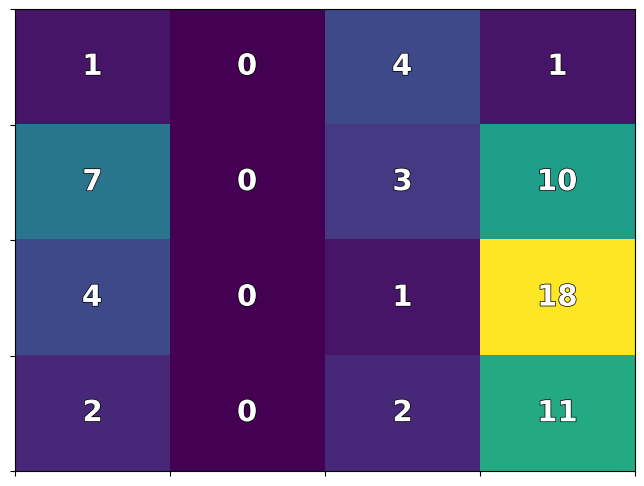

['D']


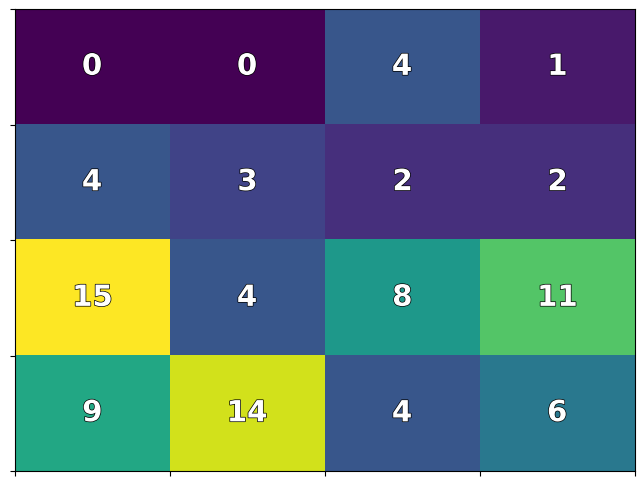

In [42]:
import matplotlib.patheffects as pe

def get_event_matrix(tide, wind):
  tidal_cycle = [(tide>=7/8)+(tide<1/8),(tide>=1/8)*(tide<3/8),(tide>=3/8)*(tide<5/8),(tide>=5/8)*(tide<7/8)]
  wind_direction = [wind<np.pi*1./4,(wind>=np.pi*1./4)*(wind<np.pi*2./4),(wind>=np.pi*2./4)*(wind<np.pi*3./4),wind>=np.pi*3./4]
  event_matrix = np.array([[np.sum(tc*wd) for tc in tidal_cycle] for wd in wind_direction])
  #print("%d %d %d %d" % (np.sum(event_matrix), len(tide), np.sum(tidal_cycle), np.sum(wind_direction)))
  return event_matrix

event_matrices_labels = [['W'],['D']]
for event_matrix_labels in event_matrices_labels:
  print(event_matrix_labels)
  event_matrices = np.zeros((len(event_matrix_labels),4,4),dtype=int)
  for i, label in enumerate(event_matrix_labels):
    tide = df.where((df.label==label)|(df.label==label+'x'),drop=True).tidal_phase
    wind = np.abs(df.where((df.label==label)|(df.label==label+'x'),drop=True).angle_wind_coast_planefit)
    event_matrices[i] += get_event_matrix(tide, wind)
  fig, ax = plt.subplots(figsize=(8,6))
  cax = ax.imshow(np.sum(event_matrices,axis=0), aspect='auto')
  #fig.colorbar(cax, ticks=[0,5,10,15], format=mticker.FixedFormatter(['0%','33%','67%','100%']))
  for i in range(event_matrices.shape[1]):
    for j in range(event_matrices.shape[2]):
      if event_matrices.shape[0] == 2:
        ax.text(j, i, "\n$\mathbf{%d}$\n%d+%d"%(np.sum(event_matrices,axis=0)[i,j],event_matrices[0,i,j],event_matrices[1,i,j]), ha="center", va="center", color="w", size=21, path_effects=[pe.withStroke(linewidth=1, foreground="black")])
      else:
        ax.text(j, i, "$\mathbf{%d}$"%(np.sum(event_matrices,axis=0)[i,j]), ha="center", va="center", color="w", size=21, path_effects=[pe.withStroke(linewidth=1, foreground="black")])
      ax.set_xticks([i-0.5 for i in range(0,5)],['' for i in range(0,5)])
      ax.set_yticks([i-0.5 for i in range(0,5)],['' for i in range(0,5)])
      #plt.title("Wettings Dryings Dryings+Beachings")
      #ax.set_xticks([0,1,2,3] ,['H','F','L','R'])
      #ax.set_yticks([0,1,2,3],['135-180° off','90-135° cross','45-90° cross','0-45° to'])
  plt.savefig("%s/groundingcharacteristics/eventsmatrix_wind_tide_%s_area_%dm"%(plots_output_root_dir,''.join(event_matrix_labels),2*coast_orientation_area_reference_radius_meters))
  plt.show()

In [43]:
import matplotlib
import matplotlib.patheffects as pe
import colorsys

def sample_cmap_rgb(v, vrange=[0.0,1.0], cmap_str='viridis'):
  cmap = matplotlib.colormaps.get_cmap(cmap_str)
  norm = matplotlib.colors.Normalize(vmin=vrange[0],vmax=vrange[1])
  rgb = cmap(norm(v))[:3]
  return rgb

def set_hsv_saturation_rgb(c_rgb, s):
  h,_,v = colorsys.rgb_to_hsv(c_rgb[0],c_rgb[1],c_rgb[2])
  return colorsys.hls_to_rgb(h,s,v)

def scale_hsv_saturation_rgb(c_rgb, f):
  _,s,_ = colorsys.rgb_to_hls(c_rgb[0],c_rgb[1],c_rgb[2])
  s_new = min(max(0.0,s+(1.-s)*f),1.0)
  return set_hsv_saturation_rgb(c_rgb,s_new)

def sample_cmap_2d_rgb(v_major, v_minor, vrange_major=[0.0,1.0], vrange_minor=[0.0,1.0], cmap_str='viridis'):
  c_rgb_major = sample_cmap_rgb(v_major,vrange_major,cmap_str)
  f = (v_minor-vrange_minor[0])/(vrange_minor[1]-vrange_minor[0]) if (vrange_minor[1]-vrange_minor[0]) else 0.0
  c_rgb_minor = scale_hsv_saturation_rgb(c_rgb_major,f*0.8)
  #print(v_major, v_minor, vrange_major, vrange_minor,f,c_rgb)
  return c_rgb_major, c_rgb_minor

def map_major_minor(vals, i, j):
  dim_X,dim_Y,dim_x,dim_y = vals.shape
  I,J = int(i/dim_x),int(j/dim_y)
  i,j = i%dim_x,j%dim_y
  v_major = np.sum(vals[I,J])
  v_minor = vals[I,J,i,j]
  vrange_major = [np.min(np.sum(vals,axis=(2,3))),np.max(np.sum(vals,axis=(2,3)))]#[np.min(vals),np.max(vals)]
  vrange_minor = [0,np.max(vals[I,J])]#[np.min(vals[I,J]),np.max(vals[I,J])]
  return v_major, v_minor, vrange_major, vrange_minor

def plot_detailed_confusion_matrix(cdm):
  dim_X,dim_Y,dim_x,dim_y = cdm.shape #phase dir dur speed #[x phase y direction [# x duration y speed]]
  mat_dim_x = dim_X * dim_x
  mat_dim_y = dim_Y * dim_y
  mat_img_minor = [[sample_cmap_2d_rgb(map_major_minor(cdm,i,j)[0],map_major_minor(cdm,i,j)[1],map_major_minor(cdm,i,j)[2],map_major_minor(cdm,i,j)[2])[1] for i in range(mat_dim_x)] for j in range(mat_dim_y)]
  fig, ax = plt.subplots(figsize=(dim_X*dim_x/2,dim_Y*dim_y/2))
  for i in range(mat_dim_x):
    for j in range(mat_dim_y):
      v = map_major_minor(cdm, i, j)[1]
      if v:
        ax.text(i, j, "$\mathbf{%d}$"%v, ha="center", va="center", color="w", size=15, path_effects=[pe.withStroke(linewidth=1, foreground="black")])
  ax.set_xticks([i-0.5 for i in range(0,mat_dim_x+1,4)],['' for i in range(0,mat_dim_x+1,4)])
  ax.set_yticks([i-0.5 for i in range(0,mat_dim_y+1,3)],['' for i in range(0,mat_dim_y+1,3)])
  ax.grid()
  ax.imshow(mat_img_minor)

<>:47: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:47: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/34/nx9zlnqn1z1cr2gtrfzmz7vw0000gp/T/ipykernel_15391/3379812940.py:47: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.text(i, j, "$\mathbf{%d}$"%v, ha="center", va="center", color="w", size=15, path_effects=[pe.withStroke(linewidth=1, foreground="black")])


test with ramdom matrix

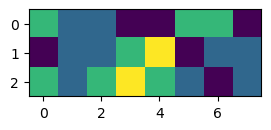

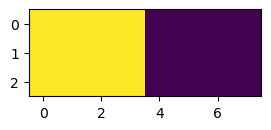

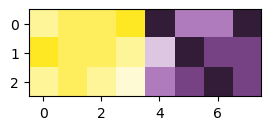

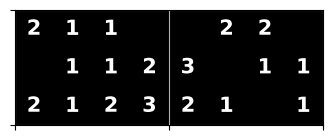

In [55]:
#dim_X,dim_Y,dim_x,dim_y=2,1,2,1
dim_X,dim_Y,dim_x,dim_y=2,1,4,3
vals = np.array(np.random.rand(dim_X,dim_Y,dim_x,dim_y)*4,dtype=int)
mat_dim_x = dim_X * dim_x
mat_dim_y = dim_Y * dim_y
#sample_cmap_2d_rgb(np.sum(vals[int(i/dim_x),int(j/dim_y)]),vals[int(i/dim_x),int(j/dim_y),i%dim_x,j%dim_y])
mat_img = [[map_major_minor(vals,i,j)[1] for i in range(mat_dim_x)] for j in range(mat_dim_y)]
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(mat_img)
plt.show()
mat_img = [[map_major_minor(vals,i,j)[0] for i in range(mat_dim_x)] for j in range(mat_dim_y)]
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(mat_img)
plt.show()
mat_img = [[sample_cmap_2d_rgb(map_major_minor(vals,i,j)[0],map_major_minor(vals,i,j)[1],map_major_minor(vals,i,j)[2],map_major_minor(vals,i,j)[3])[1] for i in range(mat_dim_x)] for j in range(mat_dim_y)]
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(mat_img)
plt.show()

plot_detailed_confusion_matrix(vals)

This section computes the actual plots

W
entry(0,0)
[[0 0 0 0]
 [0 0 0 1]
 [0 0 0 0]]
sums minor
[[ 1  0  4  1]
 [ 7  0  3 10]
 [ 4  0  1 17]
 [ 2  0  2  9]]
sum
61
D
entry(0,0)
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
sums minor
[[ 0  0  4  1]
 [ 4  3  2  2]
 [ 4  4  8 10]
 [ 8 14  4  6]]
sum
74


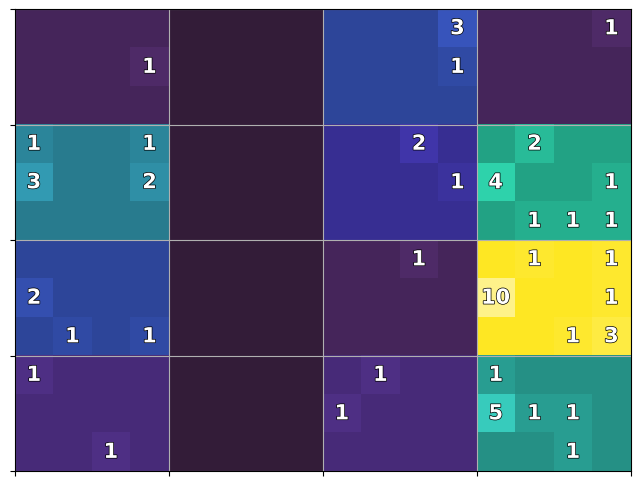

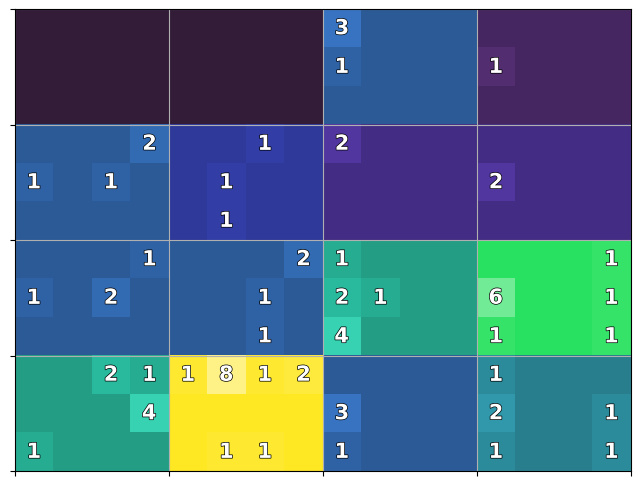

In [45]:
def crit_label(df, i):
  if i == 0:
    return df.label=='W'
  if i == 1:
    return df.label=='D'
def crit_tidal_phase(df, i):
  if np.any(df.tidal_phase < 0) | np.any(1 < df.tidal_phase):
    print("WARNING: tidal phase out of expected range [0,1]")
  if i == 0:
    return (7/8<=df.tidal_phase)|(df.tidal_phase<1/8)
  if i == 1:
    return (1/8<=df.tidal_phase)&(df.tidal_phase<3/8)
  if i == 2:
    return (3/8<=df.tidal_phase)&(df.tidal_phase<5/8)
  if i == 3:
    return (5/8<=df.tidal_phase)&(df.tidal_phase<7/8)
def crit_angle_wind_coast(df, i):
  if np.any(np.pi < np.abs(df.angle_wind_coast_planefit)):
    print("WARNING: angle wind-coas out of expected range [0,pi]")
  if i == 0:
    return np.abs(df.angle_wind_coast_planefit)<np.pi*1./4
  if i == 1:
    return (np.abs(df.angle_wind_coast_planefit)>=np.pi*1./4)&(np.abs(df.angle_wind_coast_planefit)<np.pi*2./4)
  if i == 2:
    return (np.abs(df.angle_wind_coast_planefit)>=np.pi*2./4)&(np.abs(df.angle_wind_coast_planefit)<np.pi*3./4)
  if i == 3:
    return np.abs(df.angle_wind_coast_planefit)>=np.pi*3./4
def crit_duration(df, i):
  T = 60*60*12.42
  if i == 0:
    return df.duration<T/4
  if i == 1:
    return (df.duration>=T/4)&(df.duration<T/2)
  if i == 2:
    return (df.duration>=T/2)&(df.duration<T)
  if i == 3:
    return df.duration>=T
def crit_wind_speed(df, i):
  if i == 0:
    return df.wind_speed<6.0
  if i == 1:
    return (df.wind_speed>=6.0)&(df.wind_speed<12.0)
  if i == 2:
    return df.wind_speed>=12.0

for ict, ct in enumerate(['W','D']):
  dcm = [[[[len(df.where(crit_label(df,ict)&crit_tidal_phase(df,i)&crit_angle_wind_coast(df,j)&crit_duration(df,k)&crit_wind_speed(df,2-l),drop=True).time.values) for l in range(3)] for k in range(4)] for j in range(4)] for i in range(4)]
  dcm = np.array(dcm)
  print(ct)
  print("entry(0,0)")
  print(dcm[0,0].T)
  print("sums minor")
  print(np.sum(np.sum(dcm,2),2).T)
  print("sum")
  print(np.sum(dcm))
  plot_detailed_confusion_matrix(dcm)
  plt.savefig("%s/groundingcharacteristics/eventsmatrix_detailed_%s_area_%dm" % (plots_output_root_dir,ct,2*coast_orientation_area_reference_radius_meters))
